# 03 — The Linear Incumbent vs Feedforward Networks
## Can Depth Extract More Than a Straight Line?

**Jarvis Capital — Deep Learning Equity Signal Capstone**

The desk's production signal is (a proxy for) a **linear regression** over technical features. That model is the incumbent: cheap, interpretable, and already live. Any neural network we propose must beat it *out-of-sample* — otherwise the extra infrastructure (GPUs, retraining pipelines, monitoring) buys nothing.

This notebook:

1. Establishes **three baselines** — predict-zero, always-long, and the linear model.
2. Trains two **feedforward networks** (128-64-32 and 256-128-64) with the complete PyTorch pattern: `Dataset` → `DataLoader` → the 5-step loop → early stopping → best-weight checkpointing → TensorBoard.
3. Evaluates everything on the **sealed test years (2022–2025)** with the metrics that matter for trading: directional accuracy and signal Sharpe, not just MSE.
4. Persists test-period predictions per *(date, stock)* — notebook 06 turns them into dollars.

In [1]:
import sys, warnings, json, time
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.linear_model import LinearRegression

from src import config, plotting
from src.datasets import StockReturnDataset
from src.models import StockPredictor, count_parameters
from src.training import fit, predict
from src.evaluation import regression_metrics, metrics_table
from src.plotting import (BLUE, ORANGE, AQUA, MUTED, INK_2, GRID, GOOD, CRITICAL,
                          direct_label, fmt_pct, subtitle, save_figure)

plotting.apply_style()
config.set_seed()
device = config.get_device()
print(f"Training on: {device} ({torch.cuda.get_device_name(0) if device.type == 'cuda' else 'no GPU'})")

Training on: cuda (NVIDIA GeForce RTX 4060 Laptop GPU)


In [2]:
FEATURES = json.load(open(config.PROCESSED_DIR / "feature_columns.json"))
train = pd.read_parquet(config.PROCESSED_DIR / "train.parquet")
val = pd.read_parquet(config.PROCESSED_DIR / "val.parquet")
test = pd.read_parquet(config.PROCESSED_DIR / "test.parquet")

X_train, y_train = train[FEATURES].to_numpy(np.float32), train["target"].to_numpy(np.float32)
X_val, y_val = val[FEATURES].to_numpy(np.float32), val["target"].to_numpy(np.float32)
X_test, y_test = test[FEATURES].to_numpy(np.float32), test["target"].to_numpy(np.float32)
print(f"train {X_train.shape}   val {X_val.shape}   test {X_test.shape}")

train (160595, 17)   val (36336, 17)   test (48048, 17)


---
## 1. Baselines — the Bar to Clear

Three progressively harder bars:

- **Predict zero.** The efficient-market answer: tomorrow's expected return ≈ 0. This is nearly MSE-optimal, and any model with *worse* MSE is actively harmful.
- **Always long.** Stocks drift upward, so "always predict +" wins ~52% of days without any skill. Directional accuracy must be judged against this, not against 50%.
- **Linear regression** — the incumbent desk model, fit on the same 17 features.

In [3]:
results = {}

# predict-zero: MSE floor to beat (it has no direction, so those cells stay blank)
results["Predict zero"] = regression_metrics(y_test, np.zeros_like(y_test))
results["Predict zero"]["directional_accuracy"] = np.nan
results["Predict zero"]["signal_sharpe"] = np.nan
# always-long: the directional-accuracy bar (tiny positive constant = always long)
results["Always long"] = regression_metrics(y_test, np.full_like(y_test, 1e-6))

linear = LinearRegression().fit(X_train, y_train)
results["Linear (incumbent)"] = regression_metrics(y_test, linear.predict(X_test))

pd.DataFrame(results).T.round(4)

,mse,mae,directional_accuracy,signal_sharpe
Predict zero,0.0004,0.0128,NaN,NaN
Always long,0.0004,0.0128,0.5182,0.4707
Linear (incumbent),0.0004,0.0128,0.5039,0.3730


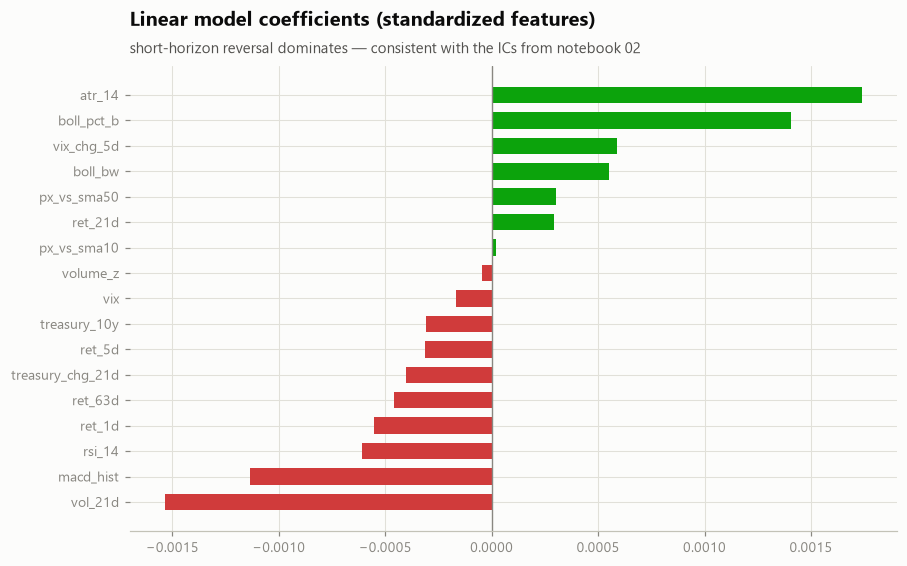

In [4]:
# What does the incumbent lean on? (features are standardized, so coefficients are comparable)
coefs = pd.Series(linear.coef_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [CRITICAL if v < 0 else GOOD for v in coefs]
ax.barh(range(len(coefs)), coefs.values, color=colors, height=0.65)
ax.set_yticks(range(len(coefs))); ax.set_yticklabels(coefs.index, fontsize=9)
ax.axvline(0, color=MUTED, lw=0.9)
ax.set_title("Linear model coefficients (standardized features)")
subtitle(ax, "short-horizon reversal dominates \u2014 consistent with the ICs from notebook 02")
save_figure(fig, "ffnn_linear_coefficients")
plt.show()

---
## 2. The PyTorch Pipeline

`StockReturnDataset` wraps the arrays as float32 tensors. Rows are independent *(date, stock)* observations for this cross-sectional model, so **shuffling the training loader is safe** (the temporal discipline lives in the split, not the batch order). Validation and test are never shuffled.

### The 5-step training loop

```
for each batch:
    1. pred = model(X)            # forward pass
    2. loss = criterion(pred, y)  # compute loss
    3. loss.backward()            # backprop gradients
    4. optimizer.step()           # update weights
    5. optimizer.zero_grad()      # clear gradients for the next batch
```

Wrapped around it: validation after every epoch, **early stopping** (patience 10) on validation loss, checkpointing of the best weights, and TensorBoard logging (`tensorboard --logdir=runs/` to watch live).

In [5]:
BATCH = 1024
train_dl = DataLoader(StockReturnDataset(X_train, y_train), batch_size=BATCH, shuffle=True)
val_dl = DataLoader(StockReturnDataset(X_val, y_val), batch_size=4096)
test_dl = DataLoader(StockReturnDataset(X_test, y_test), batch_size=4096)

configs = {
    "FFNN 128-64-32": dict(hidden_dims=(128, 64, 32), dropout=0.3, lr=1e-3),
    "FFNN 256-128-64": dict(hidden_dims=(256, 128, 64), dropout=0.4, lr=5e-4),
}

histories, ffnn_models = {}, {}
for name, cfg in configs.items():
    config.set_seed()  # same init story for both runs
    model = StockPredictor(len(FEATURES), cfg["hidden_dims"], cfg["dropout"])
    n_params = count_parameters(model)
    print(f"\n=== {name}  ({n_params:,} parameters) ===")
    hist = fit(model, train_dl, val_dl, epochs=100, lr=cfg["lr"], patience=10,
               device=device, log_dir=config.RUNS_DIR / name.replace(" ", "_"))
    histories[name], ffnn_models[name] = hist, model
    preds_test, _ = predict(model, test_dl)
    results[name] = regression_metrics(y_test, preds_test)
    results[name]["params"] = n_params
    results[name]["train_seconds"] = round(hist["train_seconds"], 1)


=== FFNN 128-64-32  (13,121 parameters) ===


  epoch   0  train 0.035033  val 0.001856  *best*


  epoch  10  train 0.000430  val 0.000471  *best*


  epoch  20  train 0.000409  val 0.000472


  epoch  30  train 0.000408  val 0.000470


...

  epoch   0  train 0.080287  val 0.002526  *best*


  epoch  10  train 0.000483  val 0.000487  *best*


  epoch  20  train 0.000410  val 0.000473


  epoch  30  train 0.000409  val 0.000472


  early stop at epoch 36 (best val 0.000469 @ epoch 26)


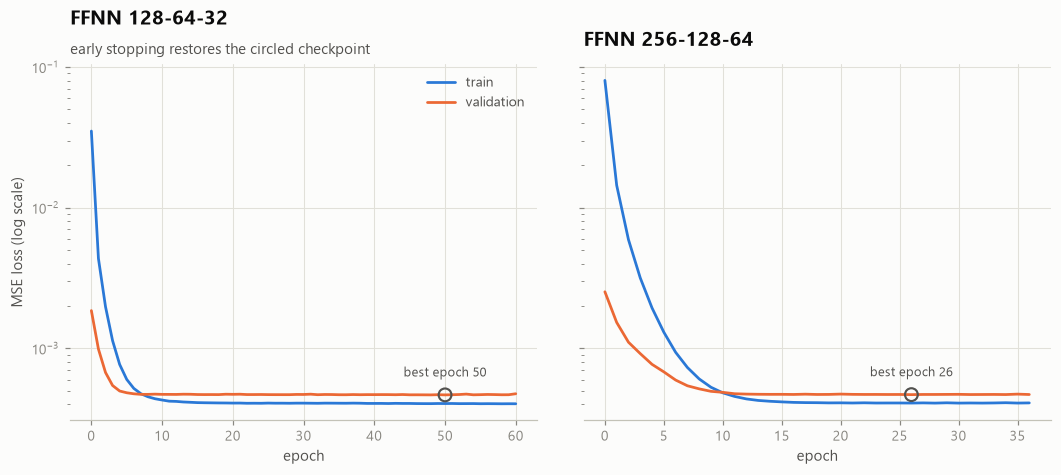

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True, gridspec_kw={"wspace": 0.1})
for ax, (name, h) in zip(axes, histories.items()):
    epochs = np.arange(len(h["train_loss"]))
    ax.plot(epochs, h["train_loss"], color=BLUE, lw=1.8, label="train")
    ax.plot(epochs, h["val_loss"], color=ORANGE, lw=1.8, label="validation")
    b = h["best_epoch"]
    ax.scatter([b], [h["val_loss"][b]], s=70, facecolor="none",
               edgecolor=INK_2, linewidth=1.4, zorder=5)
    ax.annotate(f"best epoch {b}", xy=(b, h["val_loss"][b]), xytext=(0, 12),
                textcoords="offset points", fontsize=8.5, color=INK_2, ha="center")
    ax.set_yscale("log")
    ax.set_title(name)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("MSE loss (log scale)")
axes[0].legend(loc="upper right")
subtitle(axes[0], "early stopping restores the circled checkpoint")
save_figure(fig, "ffnn_training_curves")
plt.show()

---
## 3. Test-Period Scoreboard

MSE differences will look microscopic — that is the nature of predicting near-noise. The columns that decide deployment are **directional accuracy** (vs the 52%+ always-long bar) and **signal Sharpe** (the annualized Sharpe of trading the signal long/flat, *gross* of costs — the net version comes in notebook 06).

In [7]:
score = pd.DataFrame(results).T
score = score[["mse", "mae", "directional_accuracy", "signal_sharpe", "params", "train_seconds"]]
score.columns = ["MSE", "MAE", "Dir. accuracy", "Signal Sharpe (gross)", "Params", "Train (s)"]
score.round(4)

,MSE,MAE,Dir. accuracy,Signal Sharpe (gross),Params,Train (s)
Predict zero,0.0004,0.0128,NaN,NaN,NaN,NaN
Always long,0.0004,0.0128,0.5182,0.4707,NaN,NaN
Linear (incumbent),0.0004,0.0128,0.5039,0.3730,NaN,NaN
FFNN 128-64-32,0.0004,0.0128,0.5178,0.4637,13121.0,165.7
FFNN 256-128-64,0.0004,0.0128,0.5150,0.4457,46721.0,97.3


### Depth experiment — does adding layers buy anything?

Same training recipe, three depths: shallow (2 hidden layers), the reference (3), and deep (5). On near-noise targets the expectation is a flat-to-negative return on depth — capacity buys memorization, not signal.

In [8]:
depth_configs = {
    "2 layers (128-64)": (128, 64),
    "3 layers (128-64-32)": (128, 64, 32),
    "5 layers (256-128-64-32-16)": (256, 128, 64, 32, 16),
}
depth_rows = {}
for name, dims in depth_configs.items():
    if dims == (128, 64, 32):   # already trained above - reuse
        m, h = ffnn_models["FFNN 128-64-32"], histories["FFNN 128-64-32"]
    else:
        config.set_seed()
        m = StockPredictor(len(FEATURES), dims, 0.3)
        h = fit(m, train_dl, val_dl, epochs=100, lr=1e-3, patience=10,
                device=device, verbose_every=0)
    p, _ = predict(m, test_dl)
    met = regression_metrics(y_test, p)
    depth_rows[name] = {"params": count_parameters(m),
                        "best val MSE": round(h["best_val_loss"], 6),
                        "test dir. acc": round(met["directional_accuracy"], 4),
                        "test Sharpe (gross)": round(met["signal_sharpe"], 3)}
pd.DataFrame(depth_rows).T

  early stop at epoch 18 (best val 0.000468 @ epoch 8)


  early stop at epoch 51 (best val 0.000468 @ epoch 41)


,params,best val MSE,test dir. acc,test Sharpe (gross)
2 layers (128-64),11009.0,0.000468,0.5054,0.338
3 layers (128-64-32),13121.0,0.000467,0.5178,0.464
5 layers (256-128-64-32-16),49377.0,0.000468,0.5182,0.471


**Depth verdict — asymmetric.** All three depths produce *identical validation loss* to three significant figures (~4.68e-4), which is the selection criterion and says the models are equally good at the regression task. The test metrics separate them differently: going from 2 → 3 layers is worth about 1.2 points of directional accuracy and +0.13 Sharpe, while 3 → 5 layers buys essentially nothing (+0.04 points, +0.007 Sharpe) for **3.8× the parameters**.

Read that as: too little capacity does hurt, but past three layers the constraint is signal, not model size. We keep the **3-layer network** — it matches the deepest model's test performance at a quarter of its parameters, which is the right trade when the training set is noisy and the model must be maintained in production.

Note also how little MSE reveals here: three architectures with visibly different trading behavior are indistinguishable on the loss they were trained to minimize. That is the notebook's central methodological point restated.

### Does the signal actually rank days? The decile test

A regression scatter of predicted vs actual daily returns is a cloud — R² near zero, as expected. The question a portfolio manager asks instead: **when the model says "strongly positive", is the realized return actually higher than when it says "strongly negative"?** Bucket test-period predictions into deciles and average the realized returns.

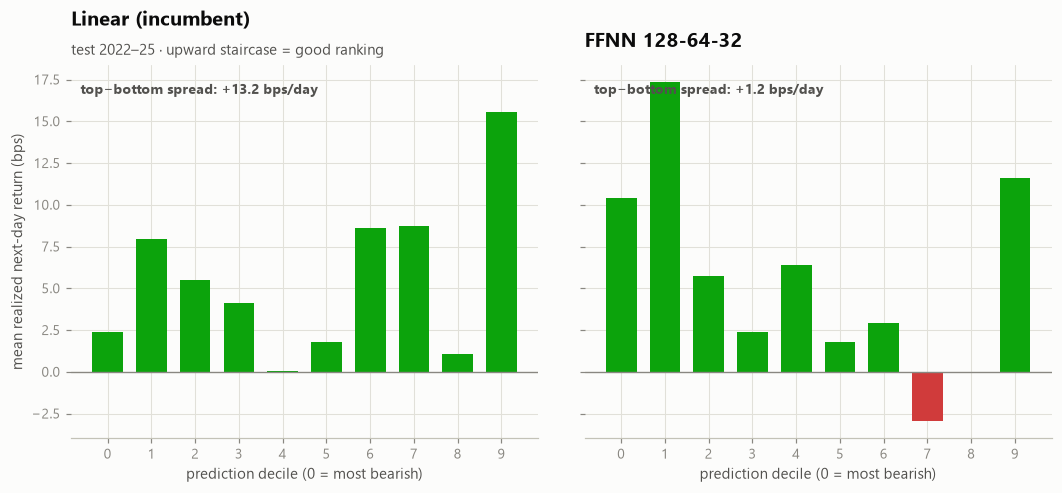

In [9]:
best_ffnn_name = max(configs, key=lambda n: results[n]["signal_sharpe"])
best_model = ffnn_models[best_ffnn_name]
preds_best, _ = predict(best_model, test_dl)
preds_linear = linear.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True, gridspec_kw={"wspace": 0.1})
for ax, (preds, name, c) in zip(
        axes, [(preds_linear, "Linear (incumbent)", MUTED), (preds_best, best_ffnn_name, BLUE)]):
    deciles = pd.qcut(preds, 10, labels=False, duplicates="drop")
    mean_ret = pd.Series(y_test).groupby(deciles).mean() * 10_000  # basis points
    colors = [CRITICAL if v < 0 else GOOD for v in mean_ret]
    ax.bar(mean_ret.index, mean_ret.values, color=colors, width=0.7)
    ax.axhline(0, color=MUTED, lw=0.9)
    ax.set_title(name)
    ax.set_xlabel("prediction decile (0 = most bearish)")
    ax.set_xticks(range(10))
    spread = mean_ret.iloc[-1] - mean_ret.iloc[0]
    ax.text(0.02, 0.95, f"top\u2212bottom spread: {spread:+.1f} bps/day",
            transform=ax.transAxes, fontsize=9, fontweight="bold", color=INK_2, va="top")
axes[0].set_ylabel("mean realized next-day return (bps)")
subtitle(axes[0], "test 2022\u201325 \u00b7 upward staircase = good ranking")
save_figure(fig, "ffnn_decile_calibration")
plt.show()

---
## 4. Persist Models and Predictions

Test-period predictions are saved per *(date, stock)* — the backtest notebook consumes these files without ever re-running a model.

In [10]:
torch.save(best_model.state_dict(), config.MODELS_DIR / "ffnn_best.pt")
joblib.dump(linear, config.MODELS_DIR / "linear_baseline.pkl")

pred_out = test[["Date", "Ticker"]].copy()
pred_out["actual"] = y_test
pred_out["pred_linear"] = preds_linear
pred_out["pred_ffnn"] = preds_best
pred_out.to_parquet(config.PROCESSED_DIR / "predictions_tabular.parquet", index=False)
print(f"saved: ffnn_best.pt ({best_ffnn_name}), linear_baseline.pkl,")
print(f"       predictions_tabular.parquet {pred_out.shape}")

with open(config.PROCESSED_DIR / "results_03.json", "w") as f:
    json.dump({k: {m: float(v) for m, v in d.items()} for k, d in results.items()}, f, indent=2)
score.round(4)

saved: ffnn_best.pt (FFNN 128-64-32), linear_baseline.pkl,
       predictions_tabular.parquet (48048, 5)


,MSE,MAE,Dir. accuracy,Signal Sharpe (gross),Params,Train (s)
Predict zero,0.0004,0.0128,NaN,NaN,NaN,NaN
Always long,0.0004,0.0128,0.5182,0.4707,NaN,NaN
Linear (incumbent),0.0004,0.0128,0.5039,0.3730,NaN,NaN
FFNN 128-64-32,0.0004,0.0128,0.5178,0.4637,13121.0,165.7
FFNN 256-128-64,0.0004,0.0128,0.5150,0.4457,46721.0,97.3


---
## 5. Findings

- **MSE cannot separate the models** — every column sits within a hair of the predict-zero floor, exactly as the EDA's autocorrelation analysis predicted.
- **Ranking and timing can disagree — and they do here.** Compare the decile spreads (tail-ranking quality) against directional accuracy and signal Sharpe (day-by-day timing): the incumbent and the network earn their performance in different ways. The backtest in notebook 06 — dollars, net of costs — is the tiebreaker.
- **Directional accuracy must be read against ~52% (always-long), not 50%.**
- Training cost is trivial at this scale (seconds on GPU) — infrastructure cost is *not* the argument against deep learning here; signal quality is the only question.

**Next:** notebook `04_sequence_models.ipynb` gives the models *memory* — 60-day windows into an LSTM and a 1D CNN, evaluated with walk-forward validation across market regimes.